In [ ]:
from labdata.schema import (
    Session,
    Dataset,
    DatasetEvents,
    SpikeSorting,
    UnitMetrics,
    UnitCountCriteria,
    EphysRecording,
    File,
)

# from labdata import chipmunk
# from chipmunk import Chipmunk

from spks.event_aligned import population_peth
from spks.viz import plot_event_aligned_raster
from spks import unpack_npix_sync
from spks.spikeglx_utils import load_spikeglx_binary

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib widget

[2026-02-27 14:02:35,518][INFO]: Connecting rojasbowe@churchland-data.cmojfwfr0b9t.us-west-2.rds.amazonaws.com:3306
[2026-02-27 14:02:35,926][INFO]: Connected rojasbowe@churchland-data.cmojfwfr0b9t.us-west-2.rds.amazonaws.com:3306


In [2]:
subject = "GRB058"
session = "20260224_152424"
sess_query = Session() & f'subject_name = "{subject}"' & f'session_name = "{session}"'

In [3]:
def apply_criteria(query, criteria):
    """takes a SpikeSorting.Unit() * UnitMetrics() query and applies criteria fetched from UnitCountCriteria()"""
    for condition in criteria.split(" & "):
        query = query & condition.strip().strip("'\"")
    return query


unit_query = (SpikeSorting.Unit() * UnitMetrics()) & sess_query
sua_criteria = (UnitCountCriteria() & "unit_criteria_id = 1").fetch("sua_criteria")[0]
good_units = apply_criteria(unit_query, sua_criteria)

In [4]:
st_per_unit = pd.DataFrame(
    good_units.fetch("unit_id", "spike_times", "depth", as_dict=True)
).spike_times.to_numpy()

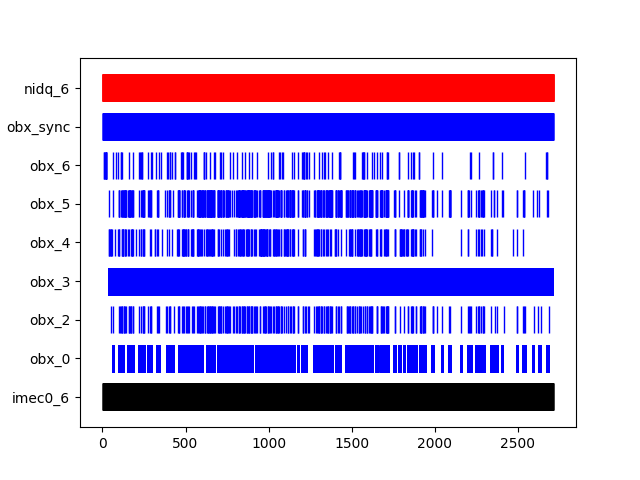

In [5]:
dset = (Dataset() & sess_query).proj()
# in order for the events to be in sync, you need to provide a StreamSync row for that dataset
# see StreamSync & dset
events = DatasetEvents.Digital() & dset
# plot the events
plt.figure()
events.plot_synced()
# get event times
events = pd.DataFrame(events.fetch_synced())

In [51]:
align_ev = {
    "stim": events.query("event_name == '0'").event_timestamps.values[0],
    "trial_start": events.query("event_name == '2'").event_timestamps.values[0],
    "frames": events.query("event_name == '3'").event_timestamps.values[0],
    "left_port": events.query("event_name == '4'").event_timestamps.values[0],
    "center_port": events.query("event_name == '5'").event_timestamps.values[0],
    "right_port": events.query(
        "event_name == '6' & stream_name == 'obx'"
    ).event_timestamps.values[0],
}

stim = align_ev["stim"]
# Each pulse is 15ms with ≥25ms gap → real onset-to-onset ≥ 40ms
# Take the first raw onset after each >20ms gap (= first onset of each pulse)
stim_ev = np.concatenate([[stim[0]], stim[1:][np.diff(stim) > 0.020]])
# First stim per trial: first onset after a >500ms gap
first_stim_ev = np.concatenate([[stim[0]], stim[1:][np.diff(stim) > 0.5]])
align_ev.update({"stim_ev": stim_ev, "first_stim_ev": first_stim_ev})

(60.0, 200.0)

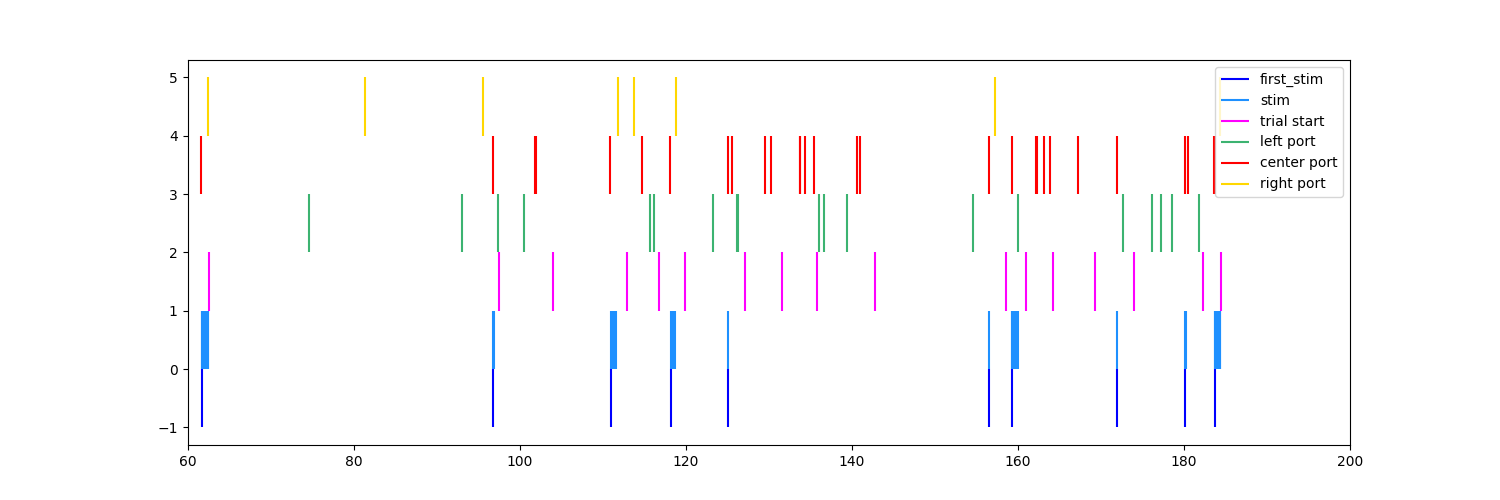

In [54]:
plt.figure(figsize=(15, 5))
plt.vlines(align_ev["first_stim_ev"], ymin=-1, ymax=0, color="blue", label="first_stim")
plt.vlines(align_ev["stim_ev"], ymin=0, ymax=1, color="dodgerblue", label="stim")
plt.vlines(
    align_ev["trial_start"], ymin=1, ymax=2, color="fuchsia", label="trial start"
)
plt.vlines(
    align_ev["left_port"], ymin=2, ymax=3, color="mediumseagreen", label="left port"
)
plt.vlines(align_ev["center_port"], ymin=3, ymax=4, color="red", label="center port")
plt.vlines(align_ev["right_port"], ymin=4, ymax=5, color="gold", label="right port")
plt.legend()
plt.xlim((60, 200))

In [ ]:
# Load the raw OBX binary to verify stim timestamps
sessions = (
    EphysRecording().proj()
    & f'subject_name = "{subject}"'
    & f'session_name = "{session}"'
)
paths = (
    File() & (Dataset.DataFiles & sessions & 'file_path LIKE "%.obx.%"')
).check_if_files_local()[0]

dat, meta = load_spikeglx_binary(paths[0])
obx_srate = meta["sRateHz"]
print(f"OBX sample rate: {obx_srate} Hz")

'imroTbl'
OBX sample rate: 30303.03012552301 Hz


In [ ]:
# 1) Check that first_stim_ev matches the first stim_ev per trial exactly
stim_ev_gaps = np.where(np.diff(stim_ev) > 0.5)[0]
first_stim_from_stim_ev = stim_ev[np.concatenate([[0], stim_ev_gaps + 1])]

n = min(len(first_stim_ev), len(first_stim_from_stim_ev))
diffs = first_stim_ev[:n] - first_stim_from_stim_ev[:n]

print("=== first_stim_ev vs first-from-stim_ev ===")
print(
    f"  Count: first_stim_ev={len(first_stim_ev)}, from stim_ev={len(first_stim_from_stim_ev)}"
)
print(f"  Max abs diff: {np.abs(diffs).max():.9f} s")
if np.allclose(diffs, 0, atol=1e-6):
    print("  ✅ Perfect match — first_stim_ev == first stim_ev per trial")
else:
    mismatches = np.where(np.abs(diffs) > 1e-6)[0]
    print(f"  ❌ {len(mismatches)} mismatches")
    for idx in mismatches[:5]:
        print(
            f"    Trial {idx}: first_stim_ev={first_stim_ev[idx]:.6f}, stim_ev={first_stim_from_stim_ev[idx]:.6f}, diff={diffs[idx] * 1000:.3f} ms"
        )

# 2) Check that every stim_ev has a matching raw onset nearby


raw_digital = dat[:, -2]
onsets_raw, _ = unpack_npix_sync(raw_digital)
stim_onsets_seconds = onsets_raw[0] / obx_srate

# For each stim_ev, find closest raw onset
closest_diffs = []
for t in stim_ev:
    idx = np.argmin(np.abs(stim_onsets_seconds - t))
    closest_diffs.append(stim_onsets_seconds[idx] - t)
closest_diffs = np.array(closest_diffs)

print("\n=== stim_ev vs raw onsets ===")
print(f"  stim_ev count: {len(stim_ev)}")
print(f"  Raw onset count: {len(stim_onsets_seconds)}")
print(
    f"  Max abs diff to nearest raw onset: {np.abs(closest_diffs).max() * 1000:.4f} ms"
)
print(f"  Mean diff: {closest_diffs.mean() * 1000:.4f} ms")
if np.all(np.abs(closest_diffs) < 0.001):
    print("  ✅ All stim_ev within 1ms of a raw onset")
else:
    bad = np.where(np.abs(closest_diffs) > 0.001)[0]
    print(f"  ❌ {len(bad)} stim_ev > 1ms from nearest raw onset")
    for idx in bad[:5]:
        print(
            f"    stim_ev[{idx}]={stim_ev[idx]:.6f}, closest raw diff={closest_diffs[idx] * 1000:.3f} ms"
        )

=== first_stim_ev vs first-from-stim_ev ===
  Count: first_stim_ev=225, from stim_ev=225
  Max abs diff: 0.000000000 s
  ✅ Perfect match — first_stim_ev == first stim_ev per trial

=== stim_ev vs raw onsets ===
  stim_ev count: 1861
  Raw onset count: 177316
  Max abs diff to nearest raw onset: 0.1997 ms
  Mean diff: 0.0094 ms
  ✅ All stim_ev within 1ms of a raw onset


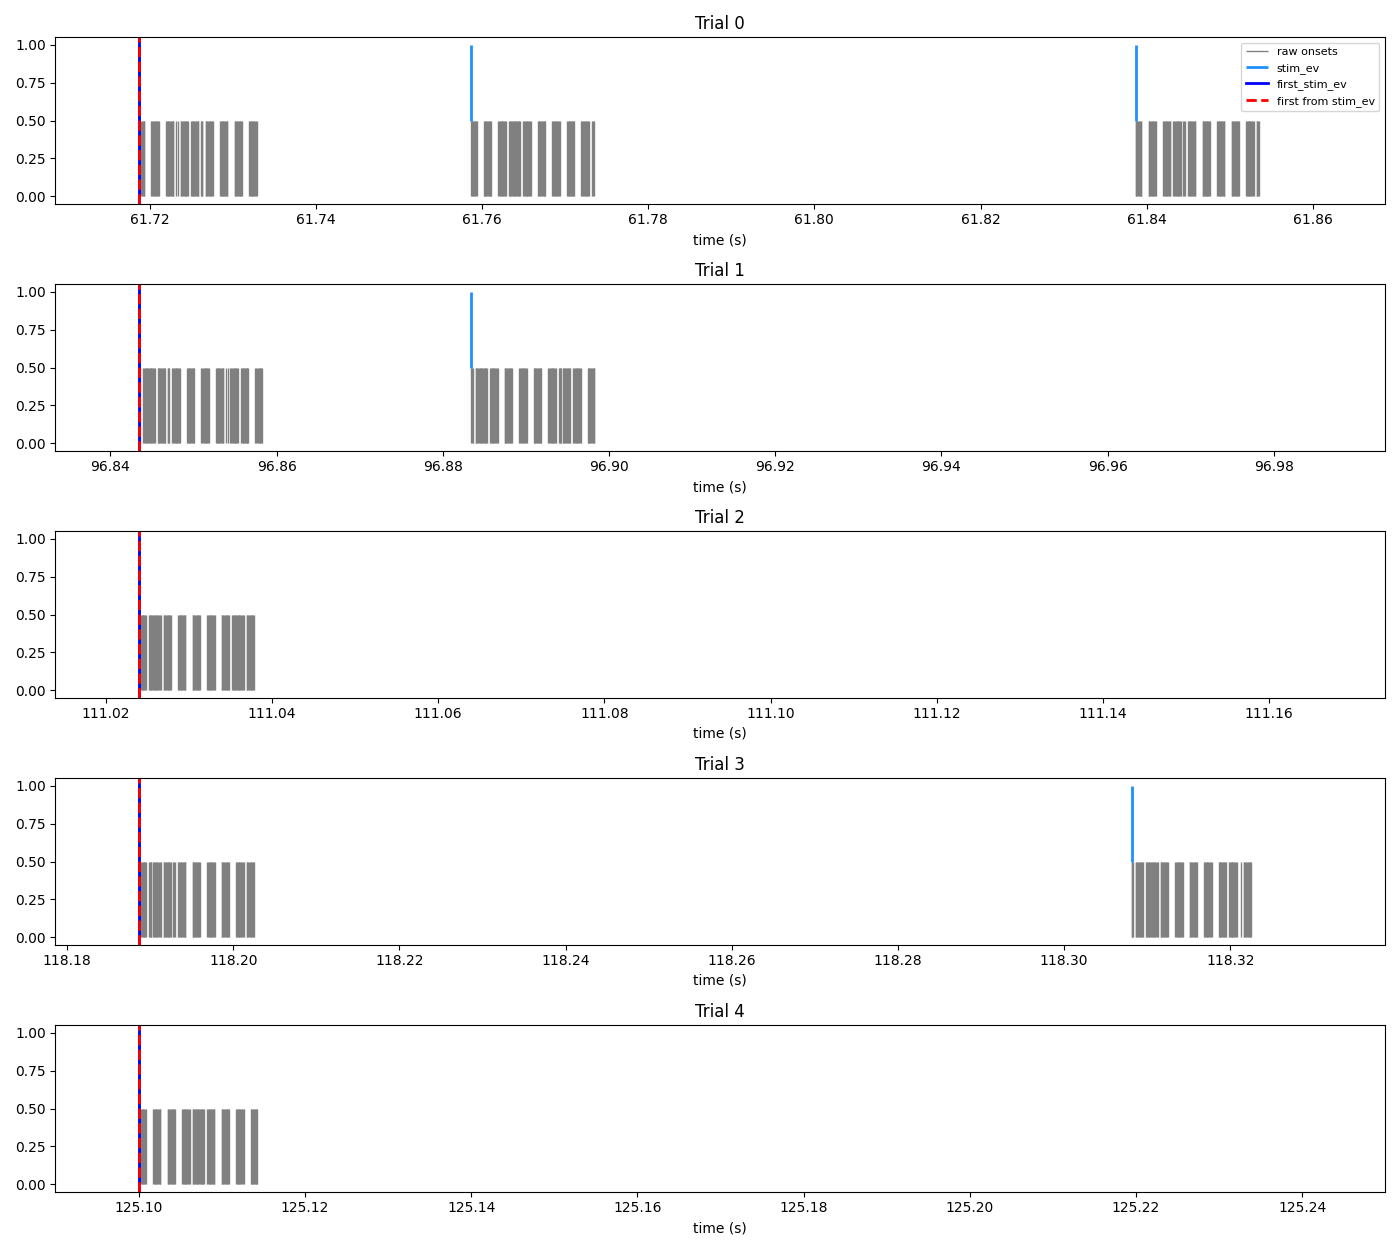

In [53]:
# Visual verification: plot stim_ev (blue) and raw onsets (grey) for first 5 trials
n_trials_to_show = 5
window_s = 0.15  # 150ms window to see several pulses

# Get first-stim indices for trial boundaries
trial_starts_idx = np.concatenate([[0], stim_ev_gaps + 1])

fig, axes = plt.subplots(
    n_trials_to_show, 1, figsize=(14, 2.5 * n_trials_to_show), sharex=False
)
for i in range(n_trials_to_show):
    ax = axes[i]

    t_center = first_stim_ev[i]
    t_start = t_center - 0.01
    t_end = t_center + window_s

    # raw onsets in window
    mask = (stim_onsets_seconds >= t_start) & (stim_onsets_seconds <= t_end)
    ax.vlines(
        stim_onsets_seconds[mask], 0, 0.5, color="grey", linewidth=1, label="raw onsets"
    )

    # stim_ev in window
    mask_ev = (stim_ev >= t_start) & (stim_ev <= t_end)
    ax.vlines(
        stim_ev[mask_ev], 0.5, 1, color="dodgerblue", linewidth=2, label="stim_ev"
    )

    # first_stim_ev
    ax.axvline(
        first_stim_ev[i],
        color="blue",
        linewidth=2,
        linestyle="-",
        label="first_stim_ev",
    )

    # first from stim_ev
    ax.axvline(
        first_stim_from_stim_ev[i],
        color="red",
        linewidth=2,
        linestyle="--",
        label="first from stim_ev",
    )

    ax.set_xlim(t_start, t_end)
    ax.set_title(f"Trial {i}")
    ax.set_xlabel("time (s)")
    if i == 0:
        ax.legend(loc="upper right", fontsize=8)

fig.tight_layout()

In [14]:
pre_seconds = 1
post_seconds = 2
binwidth_ms = 100
srate = 30000

In [15]:
import ipywidgets as widgets
from IPython.display import display

st_per_unit_s = [st / srate for st in st_per_unit]

# Create figure without auto-displaying it
with plt.ioff():
    fig, ax = plt.subplots(1, figsize=(8, 6))

unit_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(st_per_unit) - 1,
    step=1,
    description="Unit:",
    continuous_update=False,
)

event_dropdown = widgets.Dropdown(
    options=list(align_ev.keys()),
    value="stim_ev",
    description="Event:",
)


def update_plot(change):
    selected_unit = unit_slider.value
    selected_event = event_dropdown.value

    ax.cla()
    plot_event_aligned_raster(
        event_times=align_ev[selected_event],
        spike_times=st_per_unit_s[selected_unit],
        pre_seconds=pre_seconds,  # type: ignore
        post_seconds=post_seconds,  # type: ignore
        ax=ax,
    )
    ymin_plot, ymax_plot = ax.get_ylim()
    ax.vlines(x=0, ymin=ymin_plot, ymax=ymax_plot, colors="r", linestyles="--")
    ax.set_ylabel("trials")
    ax.set_xlabel("time from event (s)")
    ax.set_title(f"Unit {selected_unit} aligned to {selected_event}")
    fig.tight_layout()
    fig.canvas.draw_idle()


unit_slider.observe(update_plot, names="value")
event_dropdown.observe(update_plot, names="value")

update_plot(None)
display(widgets.VBox([unit_slider, event_dropdown, fig.canvas]))

In [ ]:
import ipywidgets as widgets
from IPython.display import display
from tqdm.notebook import tqdm_notebook

# Interactive event selection

# Create dropdown for event selection
event_selector = widgets.Dropdown(
    options=align_ev.keys(),
    value="center_port",
    description="Event:",
)

# Create output widget for plot
output = widgets.Output()


def update_plot(change):
    with output:
        output.clear_output(wait=True)

        selected_event = event_selector.value

        # Show progress indicator
        with tqdm_notebook(total=1, desc="Computing PSTH") as pbar:
            psth, timebin_edges, event_index = population_peth(
                all_spike_times=st_per_unit / srate,
                alignment_times=align_ev[selected_event],
                pre_seconds=pre_seconds,
                post_seconds=post_seconds,
                binwidth_ms=binwidth_ms,
                kernel=None,
                pad=0,
            )
            pbar.update(1)

        peak_indices = np.argmax(psth.mean(axis=1), axis=1)
        sorted_indices = np.argsort(peak_indices)
        kernel = np.mean(psth, axis=1)[sorted_indices, :]

        ### now plot
        fig, ax = plt.subplots(1, figsize=(3, 6))
        im = ax.imshow(kernel, aspect="auto", clim=(0, 30), cmap="grey_r")

        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label("sp/s")

        n_ticks = 3
        tick_step = (post_seconds + pre_seconds) / n_ticks
        binwidth_s = binwidth_ms / 1000
        zero_bin = pre_seconds / binwidth_s

        tick_times = np.concatenate(
            [
                np.arange(0, -pre_seconds - 1e-9, -tick_step)[::-1],
                np.arange(tick_step, post_seconds + 1e-9, tick_step),
            ]
        )
        tick_times = tick_times[
            (tick_times >= -pre_seconds) & (tick_times <= post_seconds)
        ]
        ticks = zero_bin + tick_times / binwidth_s
        labels = np.round(tick_times, 2)
        ax.set_xticks(ticks, labels)

        ax.set_xlabel("time from event (s)")
        ax.set_ylabel("units")
        ax.set_title(f"Aligned to: {selected_event}")

        ymin, ymax = ax.get_ylim()
        ax.vlines(zero_bin, ymin, ymax, "r", "--", alpha=0.0)

        fig.tight_layout()
        plt.show()


# Attach the callback
event_selector.observe(update_plot, names="value")

# Display widgets
display(event_selector, output)

# Trigger initial plot
update_plot(None)